Quarterly rate conversion: qq = 1 − (1 − q_annual) ^ 0.25
Applies to: KID_MORT_Q, WEANER_MORT_Q, GROWER_MORT_Q, ADULT_MORT_Q,
OFFTAKE_GROWER_Q, OFFTAKE_DOE_Q, OFFTAKE_BUCK_Q,
CULL_DOE_Q, CULL_BUCK_Q, P_KID_Q, P_WEANER_Q, P_GROWER_Q

Total population (quarterly)
kids(t+1) = kids(t) × (1 − KID_MORT_Q) × (1 − P_KID_Q) + does(t) × BIRTHS_PER_DOE_QTR
weaners(t+1) = weaners(t) × (1 − WEANER_MORT_Q) × (1 − P_WEANER_Q) + kids(t) × (1 − KID_MORT_Q) × P_KID_Q
growers(t+1) = growers(t) × (1 − GROWER_MORT_Q) × (1 − OFFTAKE_GROWER_Q) × (1 − P_GROWER_Q) + weaners(t) × (1 − WEANER_MORT_Q) × P_WEANER_Q
does(t+1) = does(t) × (1 − ADULT_MORT_Q) × (1 − CULL_DOE_Q) × (1 − OFFTAKE_DOE_Q) + growers(t) × (1 − GROWER_MORT_Q) × (1 − OFFTAKE_GROWER_Q) × P_GROWER_Q × SEX_RATIO
bucks(t+1) = bucks(t) × (1 − ADULT_MORT_Q) × (1 − CULL_BUCK_Q) × (1 − OFFTAKE_BUCK_Q) + growers(t) × (1 − GROWER_MORT_Q) × (1 − OFFTAKE_GROWER_Q) × P_GROWER_Q × (1 − SEX_RATIO)
N(t+1) = kids(t+1) + weaners(t+1) + growers(t+1) + does(t+1) + bucks(t+1)
BIRTHS_PER_DOE_QTR = KIDDING_RATE × LITTER_SIZE / 4

Meat production (quarterly)
meat_kg = does × OFFTAKE_DOE_Q × AVG_LIVE_WEIGHT_DOES × CARCASS_YIELD_DOES + bucks × OFFTAKE_BUCK_Q × AVG_LIVE_WEIGHT_BUCKS × CARCASS_YIELD_BUCKS + growers × OFFTAKE_GROWER_Q × AVG_LIVE_WEIGHT_GROWERS × CARCASS_YIELD_GROWERS

Milk production (quarterly)
milk_l = does × LACTATING_FRACTION × MILK_YIELD_L_PER_DAY × (LACTATING_DAYS / 4)

Feed intake — dry matter (quarterly)
feed_kg = kids × ((KID_W + WEANER_W) / 2) × DMI_PCT_KIDS + weaners × ((WEANER_W + GROWER_W) / 2) × DMI_PCT_WEANERS + growers × GROWER_W × DMI_PCT_GROWERS + does × DOE_W × DMI_PCT_DOES + bucks × BUCK_W × DMI_PCT_BUCKS

GOAT HERD QUARTERLY MODEL  (2020–2041)

HERD0 (2019):       34,657,969

CONVERTED QUARTERLY RATES  [qq = 1-(1-q)^(1/4)]
Parameter                      Annual   Quarterly
--------------------------------------------------
  Kid mortality                0.2400      0.0663
  Weaner mortality             0.0900      0.0233
  Grower mortality             0.0600      0.0153
  Adult mortality              0.0500      0.0127
  Offtake growers              0.1800      0.0484
  Offtake does                 0.1000      0.0260
  Offtake bucks                0.5500      0.1810
  Cull does                    0.0400      0.0102
  Cull bucks                   0.0300      0.0076
  Kid→weaner                 120.0000      0.7609
  Weaner→grower              270.0000      0.6088
  Grower→adult               540.0000      0.3382
  Births/doe/qtr               1.3200      0.3300

ANNUAL SNAPSHOT (selected years)
Year    Total Start      Total End   Meat (M kg)   Milk (M L)   Feed (M kg)
-------------------

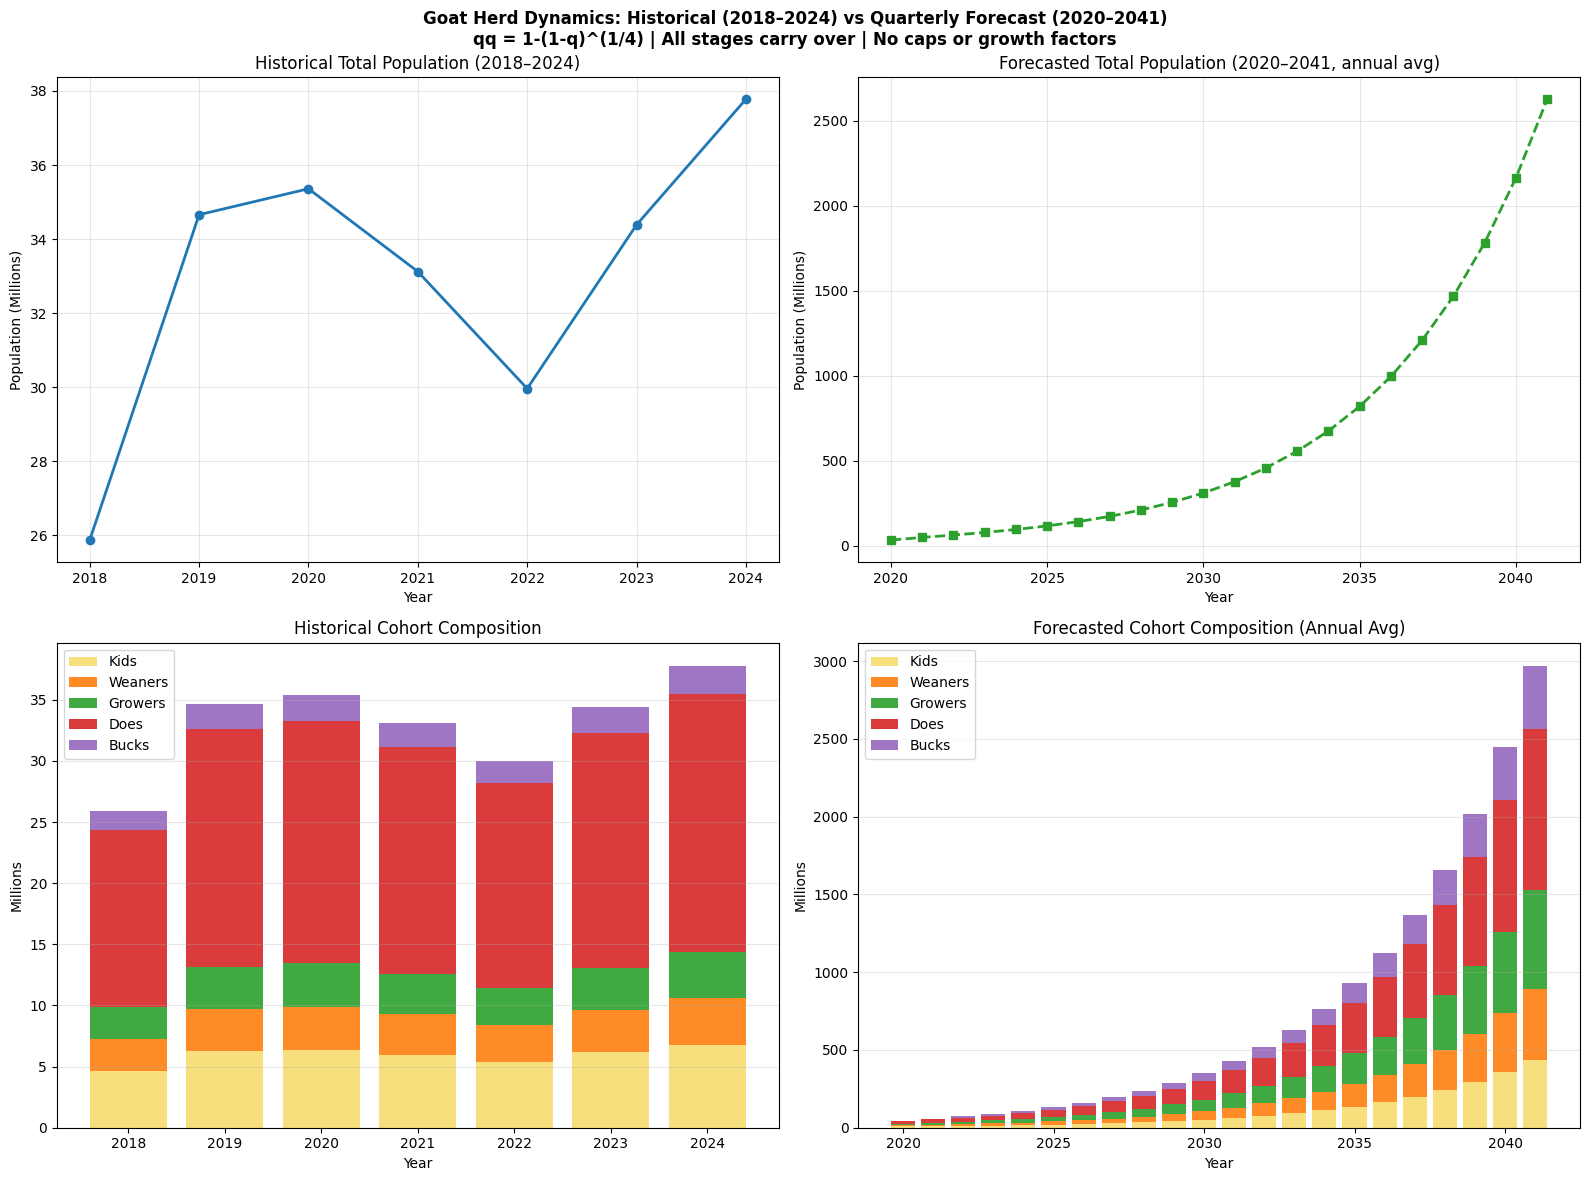

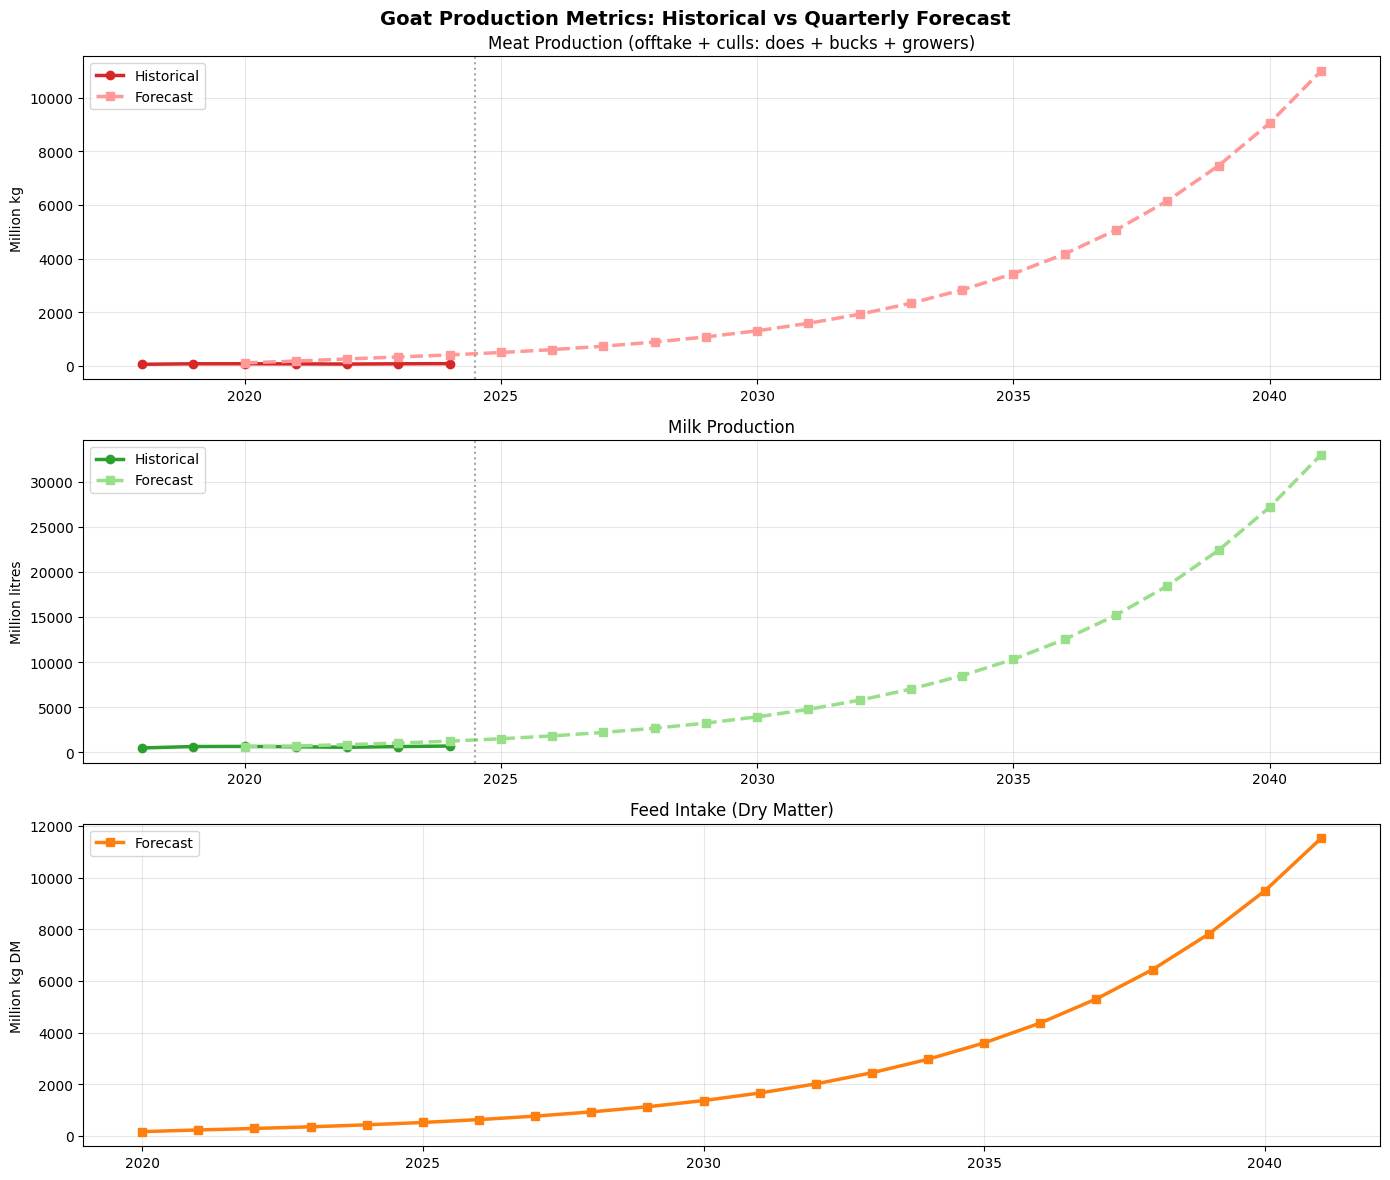

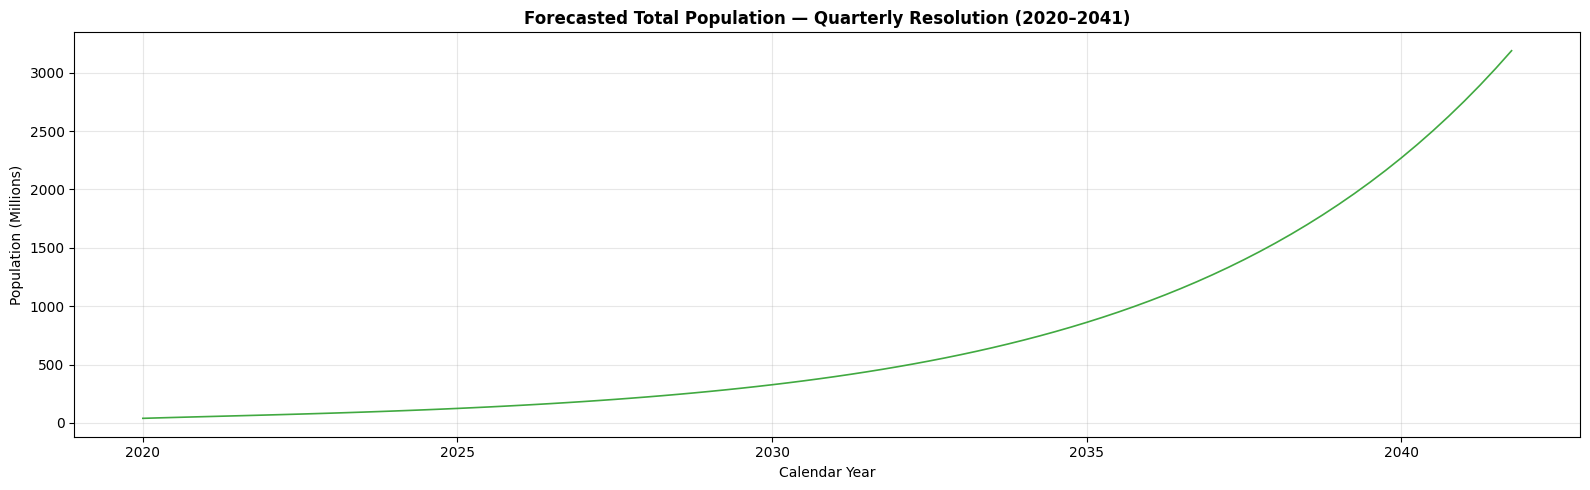

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# ============================================================================
# PARAMETERS (ANNUAL BASIS)
# ============================================================================

HISTORICAL_YEARS  = [2018, 2019, 2020, 2021, 2022, 2023, 2024]
HISTORICAL_TOTALS = [25876113, 34657969, 35358674, 33123213, 29965055, 34385998, 37776633]
HERD0 = HISTORICAL_TOTALS[HISTORICAL_YEARS.index(2019)]

SEX_RATIO    = 0.50
LITTER_SIZE  = 1.20
KIDDING_RATE = 1.10            # productivity index: kids born per doe per year

KID_MORTALITY           = 0.24
WEANER_MORTALITY        = 0.09
GROWER_MORTALITY        = 0.06
OVERALL_ADULT_MORTALITY = 0.05

OFFTAKE_RATE_GROWERS = 0.18
OFFTAKE_RATE_DOES    = 0.10
OFFTAKE_RATE_BUCKS   = 0.55

CULL_RATE_DOES_ANNUAL  = 0.04
CULL_RATE_BUCKS_ANNUAL = 0.03

PROD_PARAMS = {
    'does': {
        'carcass_yield_pct':    0.48,
        'avg_live_weight_kg':   38.0,
        'lactating_fraction':   0.40,   # used for milk only
        'milk_yield_l_per_day': 0.40,
        'lactating_days':       200
    },
    'bucks':   {'carcass_yield_pct': 0.50, 'avg_live_weight_kg': 48.0},
    'growers': {'carcass_yield_pct': 0.45, 'avg_live_weight_kg': 30.0}
}

HISTORICAL_PROPORTIONS = {
    'kids':    0.18,
    'weaners': 0.10,
    'growers': 0.10,
    'does':    0.56,
    'bucks':   0.06
}

TARGET_BUCK_PROP = 0.04

FEED_PARAMS = {
    'kids':    {'dmi_pct': 0.035, 'kid_w': 3.0,  'weaner_w': 22.0},
    'weaners': {'dmi_pct': 0.04,  'weaner_w': 22.0, 'grower_w': 30.0},
    'growers': {'dmi_pct': 0.045, 'grower_w': 30.0},
    'does':    {'dmi_pct': 0.023, 'doe_w': 38.0},
    'bucks':   {'dmi_pct': 0.023, 'buck_w': 48.0}
}

# FIX 3 — Stage durations lengthened so P_KID_Q and P_WEANER_Q no longer clamp
# to 1.0. With the old values (90/180/480 days) both P_KID_Q and P_WEANER_Q
# resolved to min(1.0, 1.015) = 1.0, clearing each cohort every single quarter
# with no accumulation. New values give realistic multi-quarter residence times.
P_KID_WEANER = 0.76
P_WEANER_GROWER = 0.50
P_GROWER_ADULT = 0.

DQ = 365.25 / 4.0

FORECAST_YEARS = 22
T_QUARTERS     = FORECAST_YEARS * 4   # 88 quarters: Q1 2020 – Q4 2041

# ============================================================================
# QUARTERLY RATE CONVERSION
# qq = 1 - (1 - q)^(1/4)
#
# Applied to: mortality, culling, offtake, transition probabilities.
# Fertility (KIDDING_RATE × LITTER_SIZE) is a production rate → divide by 4.
# ============================================================================

def to_q(q):
    """Annual probability → quarterly equivalent: qq = 1-(1-q)^(1/4)."""
    return 1.0 - (1.0 - q) ** 0.25

KID_MORT_Q       = to_q(KID_MORTALITY)
WEANER_MORT_Q    = to_q(WEANER_MORTALITY)
GROWER_MORT_Q    = to_q(GROWER_MORTALITY)
ADULT_MORT_Q     = to_q(OVERALL_ADULT_MORTALITY)
OFFTAKE_GROWER_Q = to_q(OFFTAKE_RATE_GROWERS)
OFFTAKE_DOE_Q    = to_q(OFFTAKE_RATE_DOES)
OFFTAKE_BUCK_Q   = to_q(OFFTAKE_RATE_BUCKS)
CULL_DOE_Q       = to_q(CULL_RATE_DOES_ANNUAL)
CULL_BUCK_Q      = to_q(CULL_RATE_BUCKS_ANNUAL)

# FIX 3 — min() guard retained as safety check but no longer triggers
P_KID_Q    = min(1.0, DQ / AGE_WEANING_DAYS)
P_WEANER_Q = min(1.0, DQ / (AGE_GROWER_DAYS - AGE_WEANING_DAYS))
P_GROWER_Q = min(1.0, DQ / (AGE_FIRST_KID_DAYS - AGE_GROWER_DAYS))
BIRTHS_PER_DOE_QTR = (KIDDING_RATE * LITTER_SIZE) / 4.0   # = 0.33 kids/doe/quarter

# ============================================================================
# HELPERS
# ============================================================================

def initialize_herd(total_herd):
    return {k: float(int(total_herd * v)) for k, v in HISTORICAL_PROPORTIONS.items()}

# ============================================================================
# SIMULATION
# ============================================================================

def simulate(initial_state):
    """
    Quarterly time-step, 2020–2041.

    Transition order per quarter:
        1. Mortality     — all cohorts
        2. Culling       — does and bucks only; removed animals counted for meat
        3. Offtake       — growers, does, bucks; removed animals counted for meat
        4. Maturation    — kids→weaners→growers→adults
                           Flows computed simultaneously from post-offtake stock.
                           All stages carry over; accumulation paces the pipeline.
        5. Reproduction  — surviving does produce kids

    Production & feed computed inline from actual removals (Steps 2–3) and
    end-of-period state. No carrying capacity, growth multipliers, or caps applied.
    """
    state = initial_state.copy()
    rec   = []

    dp = PROD_PARAMS['does']
    bp = PROD_PARAMS['bucks']
    gp = PROD_PARAMS['growers']
    fp = FEED_PARAMS

    for t in range(T_QUARTERS):
        year     = 2020 + t // 4
        quarter  = (t % 4) + 1
        cal_year = year + (quarter - 1) / 4.0
        total_start = sum(state.values())

        ks = state['kids']
        ws = state['weaners']
        gs = state['growers']
        ds = state['does']
        bs = state['bucks']

        # ── 1. Mortality ───────────────────────────────────────────────────
        ks *= (1.0 - KID_MORT_Q)
        ws *= (1.0 - WEANER_MORT_Q)
        gs *= (1.0 - GROWER_MORT_Q)
        ds *= (1.0 - ADULT_MORT_Q)
        bs *= (1.0 - ADULT_MORT_Q)

        # ── 2. Culling (adults only) ───────────────────────────────────────
        # FIX 2 — track removed animals; culls go to slaughter (counted in meat)
        does_culled  = ds * CULL_DOE_Q
        bucks_culled = bs * CULL_BUCK_Q
        ds -= does_culled
        bs -= bucks_culled

        # ── 3. Offtake ─────────────────────────────────────────────────────
        # FIX 2 — track removed animals; use these (not post-removal stock)
        # for meat calculation to avoid double-applying the offtake rate
        does_offtaken    = ds * OFFTAKE_DOE_Q
        bucks_offtaken   = bs * OFFTAKE_BUCK_Q
        growers_offtaken = gs * OFFTAKE_GROWER_Q
        ds -= does_offtaken
        bs -= bucks_offtaken
        gs -= growers_offtaken

        # ── 4. Maturation ──────────────────────────────────────────────────
        mk = ks * P_KID_Q
        mw = ws * P_WEANER_Q
        mg = gs * P_GROWER_Q

        ks -= mk
        ws  = ws - mw + mk
        gs  = gs - mg + mw
        ds += mg * SEX_RATIO
        bs += mg * (1.0 - SEX_RATIO)

        # ── 5. Reproduction ────────────────────────────────────────────────
        births = ds * BIRTHS_PER_DOE_QTR
        ks    += births

        state = {'kids': ks, 'weaners': ws, 'growers': gs, 'does': ds, 'bucks': bs}
        total_end = sum(state.values())

        # ── Meat — actual animals removed in steps 2 & 3 ──────────────────
        # FIX 2a: use tracked removals, not post-removal state × rate
        # FIX 2b: culled animals included (they were missing entirely before)
        meat = (
            (does_offtaken  + does_culled)  * dp['avg_live_weight_kg'] * dp['carcass_yield_pct'] +
            (bucks_offtaken + bucks_culled) * bp['avg_live_weight_kg'] * bp['carcass_yield_pct'] +
            growers_offtaken                * gp['avg_live_weight_kg'] * gp['carcass_yield_pct']
        )

        # ── Milk — lactating_fraction used here (and only here) ────────────
        milk = (ds * dp['lactating_fraction']
                * dp['milk_yield_l_per_day'] * (dp['lactating_days'] / 4.0))

        # ── Feed — computed inline from end-of-period state ────────────────
        feed = (
            ks * ((fp['kids']['kid_w']    + fp['kids']['weaner_w'])   / 2) * fp['kids']['dmi_pct'] +
            ws * ((fp['weaners']['weaner_w'] + fp['weaners']['grower_w']) / 2) * fp['weaners']['dmi_pct'] +
            gs * fp['growers']['grower_w'] * fp['growers']['dmi_pct'] +
            ds * fp['does']['doe_w']       * fp['does']['dmi_pct'] +
            bs * fp['bucks']['buck_w']     * fp['bucks']['dmi_pct']
        )

        rec.append({
            'year':        year,
            'quarter':     quarter,
            'cal_year':    cal_year,
            't':           t,
            'kids':        ks,
            'weaners':     ws,
            'growers':     gs,
            'does':        ds,
            'bucks':       bs,
            'total_start': total_start,
            'total_end':   total_end,
            'meat_kg':     meat,
            'milk_l':      milk,
            'feed_intake': feed,
        })

    return pd.DataFrame(rec)

# ============================================================================
# HISTORICAL
# ============================================================================

historical_df = pd.DataFrame({'year': HISTORICAL_YEARS, 'total': HISTORICAL_TOTALS})
for c, prop in HISTORICAL_PROPORTIONS.items():
    historical_df[c] = (historical_df['total'] * prop).astype(int)

def historical_production(df):
    out = []
    for _, r in df.iterrows():
        dp, bp, gp = PROD_PARAMS['does'], PROD_PARAMS['bucks'], PROD_PARAMS['growers']
        meat = (
            r['does']    * OFFTAKE_RATE_DOES    * dp['avg_live_weight_kg'] * dp['carcass_yield_pct'] +
            r['bucks']   * OFFTAKE_RATE_BUCKS   * bp['avg_live_weight_kg'] * bp['carcass_yield_pct'] +
            r['growers'] * OFFTAKE_RATE_GROWERS * gp['avg_live_weight_kg'] * gp['carcass_yield_pct']
        )
        milk = r['does'] * dp['lactating_fraction'] * dp['milk_yield_l_per_day'] * dp['lactating_days']
        out.append({'year': r['year'], 'meat_kg': meat, 'milk_l': milk})
    return pd.DataFrame(out)

historical_prod_df = historical_production(historical_df)

# ============================================================================
# RUN
# ============================================================================

initial_state = initialize_herd(HERD0)
forecast_df   = simulate(initial_state)

# Annual aggregates
forecast_annual = (
    forecast_df
    .groupby('year')
    .agg(
        total_start  = ('total_start', 'first'),
        total_end    = ('total_end',   'last'),
        meat_kg      = ('meat_kg',     'sum'),
        milk_l       = ('milk_l',      'sum'),
        feed_intake  = ('feed_intake', 'sum'),
        kids         = ('kids',        'mean'),
        weaners      = ('weaners',     'mean'),
        growers      = ('growers',     'mean'),
        does         = ('does',        'mean'),
        bucks        = ('bucks',       'mean'),
    )
    .reset_index()
)

# ============================================================================
# CAGR
# ============================================================================

def cagr(start, end, n):
    return (end / start) ** (1.0 / n) - 1.0

hist_pop  = historical_df
hist_prod = historical_prod_df

h_cagr_pop  = cagr(hist_pop.loc[hist_pop.year==2018,'total'].values[0],
                   hist_pop.loc[hist_pop.year==2024,'total'].values[0], 6)
h_cagr_meat = cagr(hist_prod.loc[hist_prod.year==2018,'meat_kg'].values[0],
                   hist_prod.loc[hist_prod.year==2024,'meat_kg'].values[0], 6)
h_cagr_milk = cagr(hist_prod.loc[hist_prod.year==2018,'milk_l'].values[0],
                   hist_prod.loc[hist_prod.year==2024,'milk_l'].values[0], 6)

fa0  = forecast_annual[forecast_annual.year == 2020].iloc[0]
fa22 = forecast_annual[forecast_annual.year == 2041].iloc[0]
f_cagr_pop  = cagr(fa0['total_start'], fa22['total_end'],  21)
f_cagr_meat = cagr(fa0['meat_kg'],     fa22['meat_kg'],    21)
f_cagr_milk = cagr(fa0['milk_l'],      fa22['milk_l'],     21)
f_cagr_feed = cagr(fa0['feed_intake'], fa22['feed_intake'],21)

# ============================================================================
# PRINT
# ============================================================================

print("=" * 80)
print("GOAT HERD QUARTERLY MODEL  (2020–2041)")
print("=" * 80)

print(f"\nHERD0 (2019):  {HERD0:>15,}")

print("\nCONVERTED QUARTERLY RATES  [qq = 1-(1-q)^(1/4)]")
print(f"{'Parameter':<28} {'Annual':>8}  {'Quarterly':>10}")
print("-" * 50)
rows = [
    ("Kid mortality",       KID_MORTALITY,           KID_MORT_Q),
    ("Weaner mortality",    WEANER_MORTALITY,        WEANER_MORT_Q),
    ("Grower mortality",    GROWER_MORTALITY,        GROWER_MORT_Q),
    ("Adult mortality",     OVERALL_ADULT_MORTALITY, ADULT_MORT_Q),
    ("Offtake growers",     OFFTAKE_RATE_GROWERS,    OFFTAKE_GROWER_Q),
    ("Offtake does",        OFFTAKE_RATE_DOES,       OFFTAKE_DOE_Q),
    ("Offtake bucks",       OFFTAKE_RATE_BUCKS,      OFFTAKE_BUCK_Q),
    ("Cull does",           CULL_RATE_DOES_ANNUAL,   CULL_DOE_Q),
    ("Cull bucks",          CULL_RATE_BUCKS_ANNUAL,  CULL_BUCK_Q),
    ("Kid→weaner",          AGE_WEANING_DAYS,        P_KID_Q),
    ("Weaner→grower",       AGE_GROWER_DAYS,         P_WEANER_Q),
    ("Grower→adult",        AGE_FIRST_KID_DAYS,      P_GROWER_Q),
    ("Births/doe/qtr",      KIDDING_RATE*LITTER_SIZE, BIRTHS_PER_DOE_QTR),
]
for name, ann, qtly in rows:
    print(f"  {name:<26} {ann:>8.4f}  {qtly:>10.4f}")

print("\nANNUAL SNAPSHOT (selected years)")
print(f"{'Year':>4}  {'Total Start':>13}  {'Total End':>13}  {'Meat (M kg)':>12}  {'Milk (M L)':>11}  {'Feed (M kg)':>12}")
print("-" * 72)
for _, r in forecast_annual[forecast_annual.year.isin([2020,2025,2030,2035,2041])].iterrows():
    print(f"  {int(r['year']):4d}  {r['total_start']:13,.0f}  {r['total_end']:13,.0f}  "
          f"{r['meat_kg']/1e6:12.3f}  {r['milk_l']/1e6:11.3f}  {r['feed_intake']/1e6:12.3f}")

print("\nCAGR SUMMARY")
print(f"{'Metric':<14} {'Historical 2018-2024':>22}  {'Forecast 2020-2041':>20}")
print("-" * 60)
for name, hv, fv in [("Population", h_cagr_pop, f_cagr_pop),
                      ("Meat",       h_cagr_meat, f_cagr_meat),
                      ("Milk",       h_cagr_milk, f_cagr_milk),
                      ("Feed",       float('nan'), f_cagr_feed)]:
    hstr = f"{hv:.2%}" if not np.isnan(hv) else "  n/a"
    print(f"  {name:<12} {hstr:>22}  {fv:>20.2%}")

print("=" * 80)

# ============================================================================
# VISUALIZATION 1 — HERD DYNAMICS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Goat Herd Dynamics: Historical (2018–2024) vs Quarterly Forecast (2020–2041)\n'
    'qq = 1-(1-q)^(1/4) | All stages carry over | No caps or growth factors',
    fontsize=12, fontweight='bold'
)

ax = axes[0, 0]
ax.plot(historical_df['year'], historical_df['total']/1e6, marker='o', linewidth=2, color='#1F77B4')
ax.set_title('Historical Total Population (2018–2024)')
ax.set_ylabel('Population (Millions)'); ax.set_xlabel('Year'); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(forecast_annual['year'], forecast_annual['total_start']/1e6,
        marker='s', linewidth=2, linestyle='--', color='#2CA02C')
ax.set_title('Forecasted Total Population (2020–2041, annual avg)')
ax.set_ylabel('Population (Millions)'); ax.set_xlabel('Year'); ax.grid(alpha=0.3)

coh    = ['kids', 'weaners', 'growers', 'does', 'bucks']
colors = ['#F7DC6F', '#FF7F0E', '#2CA02C', '#D62728', '#9467BD']

ax = axes[1, 0]
b = np.zeros(len(historical_df))
for c, col in zip(coh, colors):
    ax.bar(historical_df['year'], historical_df[c]/1e6, bottom=b,
           label=c.capitalize(), color=col, alpha=0.9)
    b += historical_df[c].values / 1e6
ax.set_title('Historical Cohort Composition'); ax.set_ylabel('Millions')
ax.set_xlabel('Year'); ax.legend(loc='upper left'); ax.grid(alpha=0.3, axis='y')

ax = axes[1, 1]
b = np.zeros(len(forecast_annual))
for c, col in zip(coh, colors):
    ax.bar(forecast_annual['year'], forecast_annual[c]/1e6, bottom=b,
           label=c.capitalize(), color=col, alpha=0.9)
    b += forecast_annual[c].values / 1e6
ax.set_title('Forecasted Cohort Composition (Annual Avg)')
ax.set_ylabel('Millions'); ax.set_xlabel('Year')
ax.legend(loc='upper left'); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 2 — PRODUCTION METRICS
# ============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Goat Production Metrics: Historical vs Quarterly Forecast',
             fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(historical_prod_df['year'], historical_prod_df['meat_kg']/1e6,
        marker='o', linewidth=2.5, color='#D62728', label='Historical')
ax.plot(forecast_annual['year'], forecast_annual['meat_kg']/1e6,
        marker='s', linewidth=2.5, linestyle='--', color='#FF9896', label='Forecast')
ax.set_title('Meat Production (offtake + culls: does + bucks + growers)'); ax.set_ylabel('Million kg')
ax.legend(); ax.grid(alpha=0.3)
ax.axvline(x=2024.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)

ax = axes[1]
ax.plot(historical_prod_df['year'], historical_prod_df['milk_l']/1e6,
        marker='o', linewidth=2.5, color='#2CA02C', label='Historical')
ax.plot(forecast_annual['year'], forecast_annual['milk_l']/1e6,
        marker='s', linewidth=2.5, linestyle='--', color='#98DF8A', label='Forecast')
ax.set_title('Milk Production'); ax.set_ylabel('Million litres')
ax.legend(); ax.grid(alpha=0.3)
ax.axvline(x=2024.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)

ax = axes[2]
ax.plot(forecast_annual['year'], forecast_annual['feed_intake']/1e6,
        marker='s', linewidth=2.5, color='#FF7F0E', label='Forecast')
ax.set_title('Feed Intake (Dry Matter)'); ax.set_ylabel('Million kg DM')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALIZATION 3 — QUARTERLY GRANULARITY (population only)
# ============================================================================

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(forecast_df['cal_year'], forecast_df['total_end']/1e6,
        linewidth=1.2, color='#2CA02C', alpha=0.9)
ax.set_title('Forecasted Total Population — Quarterly Resolution (2020–2041)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Population (Millions)'); ax.set_xlabel('Calendar Year')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
def build_herd_structure_table(historical_df, forecast_df):

    years = list(range(2019, 2042))

    rows = [
        "Kids",
        "Weaners",
        "Growers",
        "Does",
        "Bucks",
        "Total Goats"
    ]

    table = pd.DataFrame(index=rows, columns=years)

    # baseline
    base = historical_df[historical_df["year"] == 2019].iloc[0]

    table.loc["Kids", 2019] = base["kids"]
    table.loc["Weaners", 2019] = base["weaners"]
    table.loc["Growers", 2019] = base["growers"]
    table.loc["Does", 2019] = base["does"]
    table.loc["Bucks", 2019] = base["bucks"]
    table.loc["Total Goats", 2019] = base["total"]

    # forecast years
    for _, r in forecast_df.iterrows():

        y = int(r["year"])

        table.loc["Kids", y] = r["kids"]
        table.loc["Weaners", y] = r["weaners"]
        table.loc["Growers", y] = r["growers"]
        table.loc["Does", y] = r["does"]
        table.loc["Bucks", y] = r["bucks"]
        table.loc["Total Goats", y] = r["total_start"]

    table.insert(0, "Herd Structure", table.index)
    table.insert(0, "Value chain", "Goat")

    return table.reset_index(drop=True)

# Build the table
herd_table = build_herd_structure_table(historical_df, forecast_df)

# Save to Excel
herd_table.to_excel("herd_structure_01042026.xlsx", index=False)

In [5]:
def build_herd_tables(historical_df, forecast_annual, historical_prod_df, output_path="herd_structure.xlsx"):
    """
    Sheet 1 — Herd Structure:
        Rows: Kids, Weaners, Growers, Does, Bucks, Total Goats
        Two row-groups per cohort: "Actual" (historical observed) and "Model" (forecast)
        Columns: 2018–2041

    Sheet 2 — Production Metrics:
        Rows: Total Population, Meat Production (kg), Milk Production (L), Feed Intake (kg DM)
        Two row-groups: "Actual" and "Model"
        Columns: 2018–2041

    Actual  : historical_df / historical_prod_df — observed values for 2018–2024, NaN beyond
    Model   : forecast_annual — model output for 2020–2041, NaN before
    Overlap : 2020–2024 has both rows populated, enabling direct comparison
    """
    years = list(range(2018, 2042))

    # ── SHEET 1: Herd Structure ───────────────────────────────────────────────
    cohort_rows = ["Kids", "Weaners", "Growers", "Does", "Bucks", "Total Goats"]
    sources     = ["Actual", "Model"]

    # MultiIndex: (Cohort, Source)
    index1 = pd.MultiIndex.from_product([cohort_rows, sources], names=["Cohort", "Source"])
    sheet1 = pd.DataFrame(index=index1, columns=years, dtype=object)

    # Actual — historical observed (2018–2024)
    for _, r in historical_df.iterrows():
        y = int(r["year"])
        sheet1.loc[("Kids",        "Actual"), y] = r["kids"]
        sheet1.loc[("Weaners",     "Actual"), y] = r["weaners"]
        sheet1.loc[("Growers",     "Actual"), y] = r["growers"]
        sheet1.loc[("Does",        "Actual"), y] = r["does"]
        sheet1.loc[("Bucks",       "Actual"), y] = r["bucks"]
        sheet1.loc[("Total Goats", "Actual"), y] = r["total"]

    # Model — forecast (2020–2041)
    for _, r in forecast_annual.iterrows():
        y = int(r["year"])
        sheet1.loc[("Kids",        "Model"), y] = r["kids"]
        sheet1.loc[("Weaners",     "Model"), y] = r["weaners"]
        sheet1.loc[("Growers",     "Model"), y] = r["growers"]
        sheet1.loc[("Does",        "Model"), y] = r["does"]
        sheet1.loc[("Bucks",       "Model"), y] = r["bucks"]
        sheet1.loc[("Total Goats", "Model"), y] = r["total_start"]

    sheet1 = sheet1.reset_index()
    sheet1.insert(0, "Value Chain", "Goat")

    # ── SHEET 2: Production Metrics ───────────────────────────────────────────
    prod_rows = [
        "Total Population",
        "Meat Production (kg)",
        "Milk Production (L)",
        "Feed Intake (kg DM)",
    ]
    index2 = pd.MultiIndex.from_product([prod_rows, sources], names=["Metric", "Source"])
    sheet2 = pd.DataFrame(index=index2, columns=years, dtype=object)

    # Actual — historical observed (2018–2024)
    for _, r in historical_df.iterrows():
        y = int(r["year"])
        sheet2.loc[("Total Population", "Actual"), y] = r["total"]

    for _, r in historical_prod_df.iterrows():
        y = int(r["year"])
        sheet2.loc[("Meat Production (kg)", "Actual"), y] = r["meat_kg"]
        sheet2.loc[("Milk Production (L)",  "Actual"), y] = r["milk_l"]
        # Feed: not observed historically — remains NaN

    # Model — forecast (2020–2041)
    for _, r in forecast_annual.iterrows():
        y = int(r["year"])
        sheet2.loc[("Total Population",      "Model"), y] = r["total_end"]
        sheet2.loc[("Meat Production (kg)",  "Model"), y] = r["meat_kg"]
        sheet2.loc[("Milk Production (L)",   "Model"), y] = r["milk_l"]
        sheet2.loc[("Feed Intake (kg DM)",   "Model"), y] = r["feed_intake"]

    sheet2 = sheet2.reset_index()
    sheet2.insert(0, "Value Chain", "Goat")

    # ── WRITE ─────────────────────────────────────────────────────────────────
    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        sheet1.to_excel(writer, sheet_name="Herd Structure",     index=False)
        sheet2.to_excel(writer, sheet_name="Production Metrics", index=False)

    return sheet1, sheet2


# ── CALL ──────────────────────────────────────────────────────────────────────
sheet1, sheet2 = build_herd_tables(
    historical_df,
    forecast_annual,
    historical_prod_df,
    output_path="goats_01042026.xlsx"
)